# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [1]:
%pip install qiskit

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path

## Session Management

Save/load your session to avoid re-registering.

In [43]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [44]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

Resumed: 453 | Score: 0 | Budget: 75


## Step 1: Register

Skip this if you resumed a session above.

In [6]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "453"
    PLAYER_NAME = "Shane"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location="remote")
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as 453


## Step 2: Select Starting Node

In [46]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("Algiers, Algeria")
    print(result)

Select a starting node from the candidates shown above.
{'ok': True, 'data': {'success': True, 'starting_node': 'Algiers, Algeria', 'score': 0, 'budget': 76}}


## Step 3: Explore the Network

In [8]:
# client.print_status()

In [9]:
# Visualize the network (focused around your nodes)
# viz = GraphTool(client.get_cached_graph())
# owned = set(client.get_status().get('owned_nodes', []))
# viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [32]:
def finite_x(qc,qubit_pairs,until = 1):
    if until >= qubit_pairs:
        raise("Error")
    for i in range(until):
        qc.cx(qubit_pairs-1,i)
        qc.cx(qubit_pairs,qubit_pairs+i+1)

def omni_x(qc,qubit_pairs):
    for i in range(qubit_pairs-1):
        qc.cx(qubit_pairs-1,i)
        qc.cx(qubit_pairs,qubit_pairs+i+1)

# def finite_z(qc,qubit_pairs,until = 1): ## NOT PROPERLY CODED YET
#     if until >= qubit_pairs:
#         raise("Error")
#     for i in range(until):
#         qc.cx(qubit_pairs-1,i)
#         qc.cx(qubit_pairs,qubit_pairs+i+1)

def omni_z(qc,qubit_pairs):
    i = 0

def finite_xz(qc,qubit_pairs):
    if qubit_pairs!=3:
        raise("Error. Needs 3 pairs, minimum")
   
    qc.cx(2,1)
    qc.cx(0,1)
    qc.h(0)
    
    qc.cx(3,4)
    qc.cx(5,4)
    qc.h(5)

    qc.measure(0,0)
    qc.measure(1,1)
    qc.measure(4,4)
    qc.measure(5,5)



In [33]:
def storage(qc,flag):
    qc.reset(0)  # Reuse qubit 0 for flag
    with qc.if_test((qc.clbits[0], 1)):
        qc.x(0)
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(0)
    qc.measure(0, flag)

In [34]:
qc = QuantumCircuit(4, 2)
qc.num_qubits

4

In [49]:
def create_x():
    qubit_pairs = 2
    qc = QuantumCircuit(qubit_pairs*2, 3)
    
    qc.cx(qubit_pairs-1, 0)
    qc.cx(qubit_pairs, qubit_pairs+1)

    qc.measure(0, 0)
    qc.measure(3, 1)
    
    # Flag calculation: c[2] = c[0] AND c[1]
    # If both 0 or both 1: c[2] = 0 (keep)
    # If different: c[2] = 1 (discard)
    storage(qc,2)
    return qc

def create_z():
    qubit_pairs = 2
    qc = QuantumCircuit(qubit_pairs*2, 3)

    qc.cx(0 ,qubit_pairs-1)
    qc.h(0)
    qc.cx(qubit_pairs*2-1,qubit_pairs)  
    qc.h(qubit_pairs*2-1)     

    qc.measure(0, 0)
    qc.measure(3, 1)

    # Flag calculation: c[2] = c[0] AND c[1]
    # If both 0 or both 1: c[2] = 0 (keep)
    # If different: c[2] = 1 (discard)
    storage(qc,2)
    return qc


def create_id():
    qc = QuantumCircuit(2, 1)
    return qc


def create_xz():
    qubit_pairs = 3
    flag = 2
    qc = QuantumCircuit(qubit_pairs*2, qubit_pairs*2)
    finite_xz(qc,qubit_pairs)
    storexz(qc,flag)
    '''qc.measure(0,0)
    qc.measure(1,1)
    qc.measure(4,4)
    qc.measure(5,5)'''
    return qc

In [62]:
def storexz(qc,flag):
    qc.reset(0)  # Reuse qubit 0 for flag
    qc.reset(5)
    qc.reset(1)
    with qc.if_test((qc.clbits[0], 1)):
        qc.x(0)
    with qc.if_test((qc.clbits[5], 1)):
        qc.x(0)
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(5)
    with qc.if_test((qc.clbits[4], 1)):
        qc.x(5)
    
    
    qc.x(1)
    qc.x(0)
    qc.x(5)
    #qc.ccx(0,5,1)
    #Toffoli
    qc.t(0)
    qc.cx(0,5)
    qc.tdg(5)
    qc.cx(0,5)
    qc.t(5)
    qc.cx(5,1)
    qc.tdg(1)
    qc.cx(0,1)
    qc.t(1)
    qc.cx(5,1)
    qc.tdg(1)
    qc.cx(0,1)
    qc.t(1)
    #End Toffoli
    qc.x(5)
    qc.x(0)
    qc.measure(1, flag)
    
 

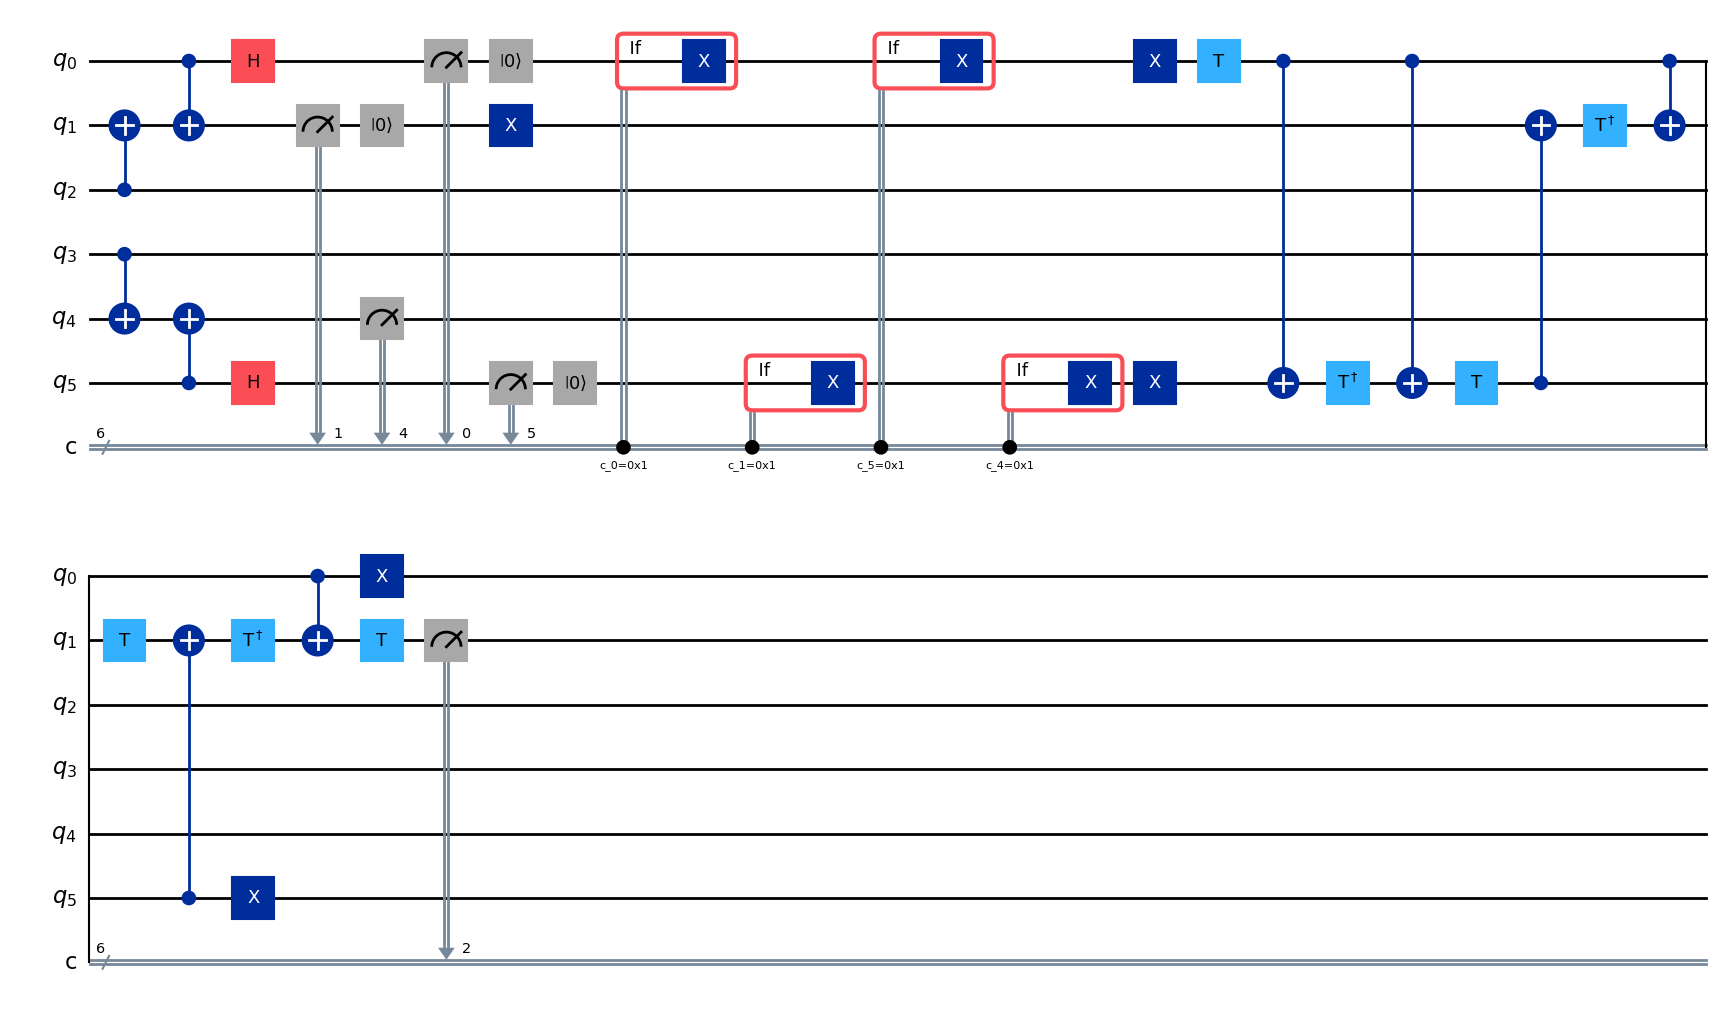

In [63]:
def create_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)
    
    return qc

# create_distillation_circuit = create_id
# create_distillation_circuit = create_x
# create_distillation_circuit = create_z
create_distillation_circuit = create_xz

circuit = create_distillation_circuit() #create_id() #create_x() #create_distillation_circuit()
circuit.draw("mpl")

## Step 5: Claim an Edge

In [64]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted[:5]:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (4):
  ['Algiers, Algeria', 'Valencia, Spain'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Tunis, Tunisia'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Barcelona, Spain'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Madrid, Spain'] - threshold: 0.920, difficulty: 4


In [65]:
# Claim an edge
if claimable:
    target = claimable_sorted[0]  # Easiest edge
    edge_id = tuple(target['edge_id'])
    
    circuit = create_distillation_circuit()
    num_bell_pairs = 3
    flag_bit = 2  # Classical bit for post-selection (keep when flag=0)
    
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")

Claiming ('Algiers, Algeria', 'Valencia, Spain') (threshold: 0.900)...


HTTPError: 400 Client Error: Bad Request for url: https://demo-entanglement-distillation-qfhvrahfcq-uc.a.run.app/v1/claim_edge

## Step 6: Check Progress

In [18]:
client.print_status()

Player: 453 (Shane)
Score: 0 | Budget: 76 bell pairs
Active: Yes
Starting node: Algiers, Algeria
Owned: 1 nodes, 0 edges
Claimable edges: 4
  - ['Algiers, Algeria', 'Valencia, Spain']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Tunis, Tunisia']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Barcelona, Spain']: threshold=0.90, difficulty=3
  ... and 1 more


In [19]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. riverst03            Score: 270
2. victor_prime         Score: 266
3. tumcuctom            Score: 196
4. ahkatlio_76f0869e    Score: 195
5. matcha_cat_42        Score: 183
6. xstm                 Score: 166
7. test_claude_1523b    Score: 163
8. A_PASTAR             Score: 160
9. evanli_nyu2          Score: 155
10. tazmondicious II     Score: 136


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [ ]:
#Restart game (uncomment to use)
#result = client.restart()
#print(result)

{'ok': True, 'data': {'success': True, 'budget': 75, 'is_active': True, 'starting_candidates': [{'node_id': 'Hefei, China', 'utility_qubits': 4, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 31.8206, 'longitude': 117.2272}, {'node_id': 'Lausanne, Switzerland', 'utility_qubits': 2, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 46.5197, 'longitude': 6.6323}, {'node_id': 'Tokyo, Japan', 'utility_qubits': 5, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 35.6762, 'longitude': 139.6503}, {'node_id': 'Algiers, Algeria', 'utility_qubits': 4, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 36.7538, 'longitude': 3.0588}]}}
